100%|██████████| 9.91M/9.91M [00:00<00:00, 38.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.04MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.61MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.36MB/s]


Epoch 1, Loss: 189.55119065755207
Epoch 2, Loss: 167.76780862630207
Epoch 3, Loss: 163.88972841796874
Epoch 4, Loss: 161.78363865559896
Epoch 5, Loss: 160.13927075195312
Epoch 6, Loss: 158.81934291992187
Epoch 7, Loss: 157.7494693033854
Epoch 8, Loss: 156.80371656901042
Epoch 9, Loss: 155.9022060546875
Epoch 10, Loss: 155.13710594075522


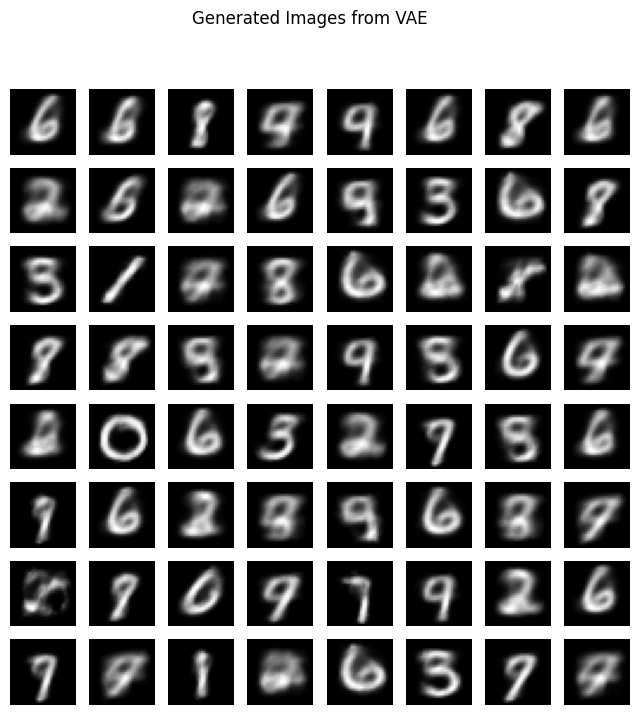

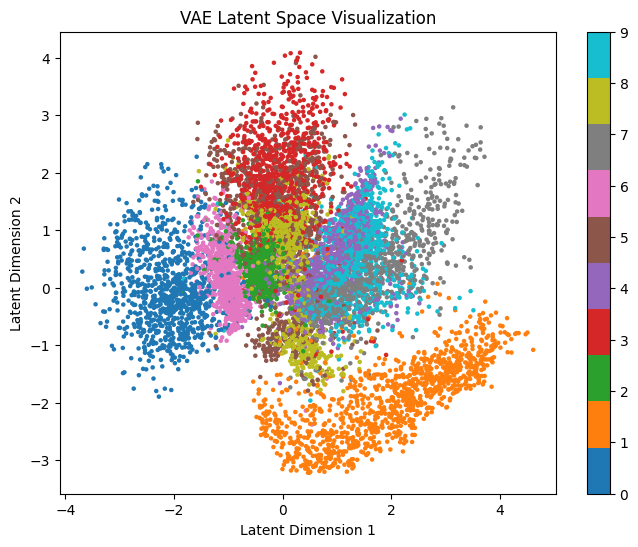

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

batch_size = 128
latent_dim = 2
epochs = 10
lr = 1e-3

transform = transforms.ToTensor()

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        self.fc1 = nn.Linear(28*28, 400)
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        self.fc2 = nn.Linear(latent_dim, 400)
        self.fc3 = nn.Linear(400, 28*28)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        x = x.view(-1, 28*28)
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

def loss_function(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(
        recon_x, x.view(-1, 28*28), reduction='sum'
    )

    KLD = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return BCE + KLD

model = VAE()
optimizer = optim.Adam(model.parameters(), lr=lr)

for epoch in range(epochs):
    total_loss = 0

    for data, _ in train_loader:

        optimizer.zero_grad()

        recon, mu, logvar = model(data)

        loss = loss_function(recon, data, mu, logvar)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader.dataset)}")

with torch.no_grad():
    z = torch.randn(64, latent_dim)
    samples = model.decode(z).view(-1, 1, 28, 28)

fig, axes = plt.subplots(8, 8, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i][0], cmap='gray')
    ax.axis('off')
plt.suptitle("Generated Images from VAE")
plt.show()

latent_vectors = []
labels = []

model.eval()

with torch.no_grad():
    for data, label in test_loader:

        data = data.view(-1, 28*28)
        mu, logvar = model.encode(data)

        latent_vectors.append(mu.numpy())
        labels.append(label.numpy())

latent_vectors = np.concatenate(latent_vectors)
labels = np.concatenate(labels)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    latent_vectors[:, 0],
    latent_vectors[:, 1],
    c=labels,
    cmap='tab10',
    s=5
)

plt.colorbar(scatter)
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("VAE Latent Space Visualization")

plt.show()